>
---
packages imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # For heatmaps
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set plot style
plt.style.use('ggplot')

df = pd.read_csv('../data/ml_raw_data/heart.csv')

# Drop duplicates to ensure the model actually has to learn patterns
df = df.drop_duplicates()

print(f"New shape: {df.shape}") 

# Check for missing values in the dataset
print(df.isnull().sum())

# See the first few rows
df.head()

New shape: (302, 14)
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


>
---
Exploratory Data Analysis (EDA)

target
1    164
0    138
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_34596\338361284.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='magma')


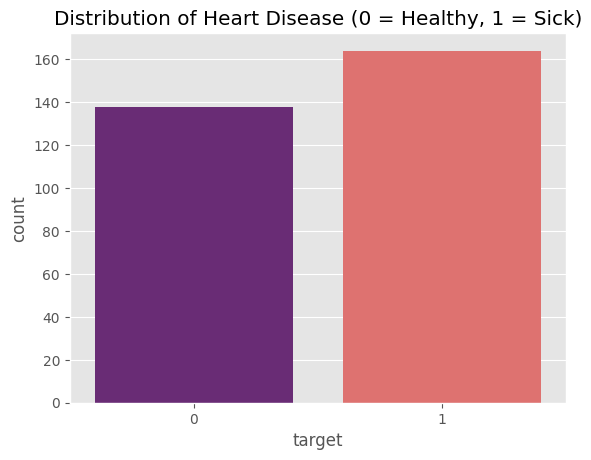

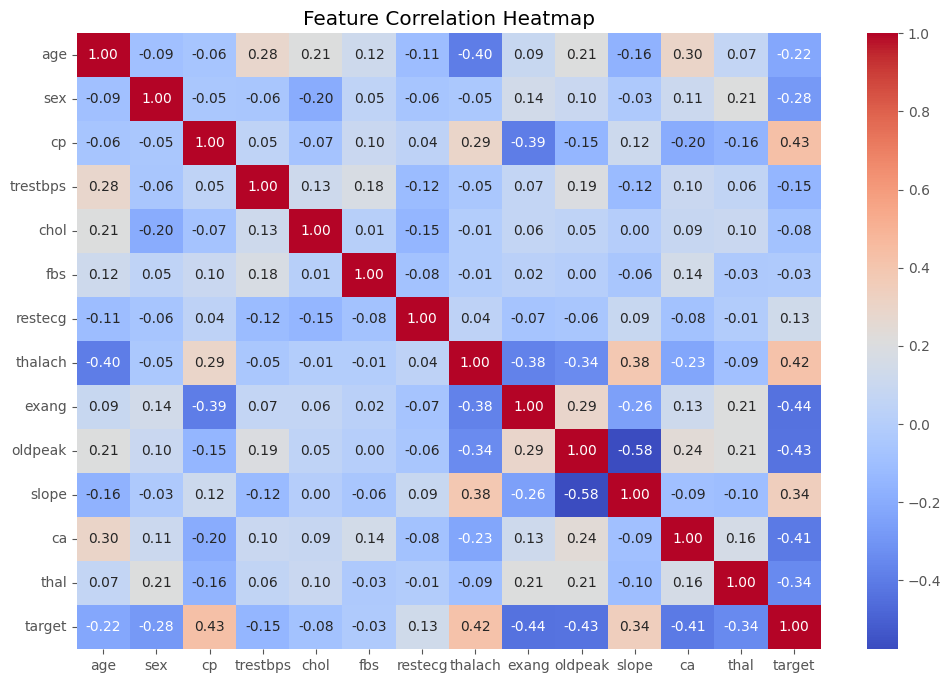

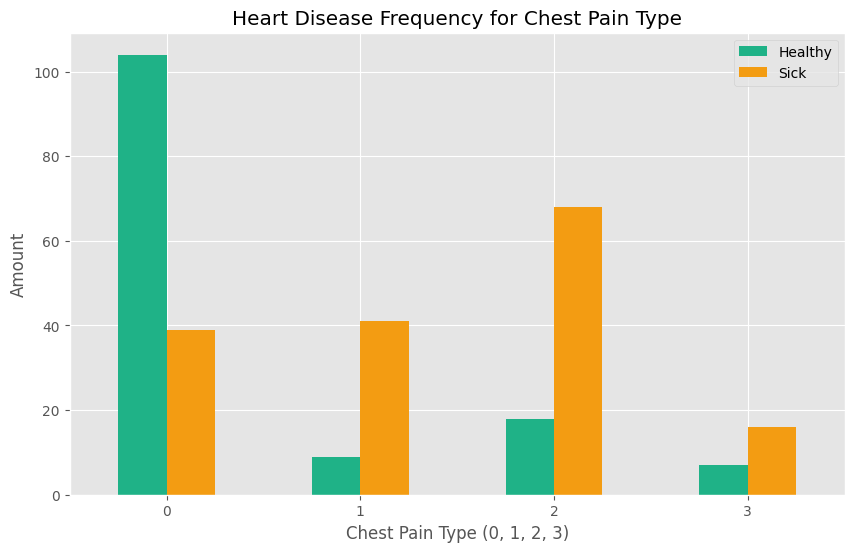

In [17]:
# Check the distribution of the target variable
print(df['target'].value_counts())

# Visualize it
sns.countplot(x='target', data=df, palette='magma')
plt.title('Distribution of Heart Disease (0 = Healthy, 1 = Sick)')
plt.show()

#The Correlation Heatmap ("Hero Features")
plt.figure(figsize=(12, 8))
# We calculate correlation and plot it
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# How does Chest Pain type relate to Heart Disease?
pd.crosstab(df.cp, df.target).plot(kind="bar", figsize=(10, 6), color=["#1fb287", "#f39c12"])
plt.title('Heart Disease Frequency for Chest Pain Type')
plt.xlabel('Chest Pain Type (0, 1, 2, 3)')
plt.ylabel('Amount')
plt.legend(["Healthy", "Sick"])
plt.xticks(rotation=0)
plt.show()

>
---
Data Engineering: Handling Categorical Variables & Splitting and Scaling

In [18]:


# Force the model to care about old age + high blood pressure
df['cardio_risk_score'] = df['age'] * (df['trestbps'] / 100)

# Convert these into dummy/indicator variables
# drop_first=True helps avoid the "dummy variable trap" (multi-collinearity)
df_final = pd.get_dummies(df, columns=['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'], drop_first=True)

# Verify the new columns (e.g., cp_1, cp_2, etc.)
print(f"New shape after dummies: {df_final.shape}")


# 1. Define Features and Target
X = df_final.drop('target', axis=1)
y = df_final['target']

# 2. Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Cast the numerical columns to float64 so they can hold decimal values
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'cardio_risk_score']

X_train[num_cols] = X_train[num_cols].astype('float64')
X_test[num_cols] = X_test[num_cols].astype('float64')

# 4. Initialize Scaler
scaler = StandardScaler()

# 5. FIT and TRANSFORM Training Data
X_train.loc[:, num_cols] = scaler.fit_transform(X_train[num_cols])

# 6. Transform Test Data (Using the mean/std from Training)
X_test.loc[:, num_cols] = scaler.transform(X_test[num_cols])


print("Scaling complete and scaler saved to /models.")
X_train.head()

New shape after dummies: (302, 24)
Scaling complete and scaler saved to /models.


,age,trestbps,chol,thalach,oldpeak,cardio_risk_score,sex_1,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
163,-0.682633,-0.403153,0.486281,0.717007,-0.447524,-0.692784,True,False,False,False,...,False,True,False,False,False,False,False,False,False,True
291,0.403989,-0.171406,0.206315,-0.836627,1.768032,0.156796,True,False,False,False,...,True,True,False,False,True,False,False,False,False,True
280,-1.008619,-0.055533,-0.260295,1.105415,-0.358902,-0.751655,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
85,-1.117282,-0.634899,-0.521596,0.889633,-0.890635,-1.080636,True,True,False,False,...,False,False,True,False,False,False,False,False,True,False
239,0.838637,1.103201,-0.073651,0.199129,0.350076,1.239550,False,False,False,False,...,True,True,False,False,False,False,False,False,True,False


>
---
Model Brain

In [19]:

models = {
    "Random Forest": RandomForestClassifier(
    n_estimators=100,      # More trees
    max_depth=7,           # Limit depth to prevent new overfitting
    min_samples_split=5,   # Don't split if there are too few samples
    random_state=42
    ),
    "XGBoost": XGBClassifier( eval_metric='logloss', random_state=42),
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
}

threshold = 0.37

# Training and Evaluation Loop
for name, model in models.items():
    model.fit(X_train, y_train)
    
    # Instead of a hard 0 or 1, we get the % chance of heart disease
    probs = model.predict_proba(X_test)[:, 1]

    custom_preds = (probs >= threshold).astype(int)

    print(f"\n================ {name} (Threshold: {threshold}) ================")
    print("Accuracy Score:", accuracy_score(y_test, custom_preds))
    print(classification_report(y_test, custom_preds, target_names=['No Heart Disease', 'Heart Disease']))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, custom_preds))




================ Random Forest (Threshold: 0.37) ================
Accuracy Score: 0.7049180327868853
                  precision    recall  f1-score   support

No Heart Disease       0.85      0.53      0.65        32
   Heart Disease       0.63      0.90      0.74        29

        accuracy                           0.70        61
       macro avg       0.74      0.71      0.70        61
    weighted avg       0.75      0.70      0.70        61

Confusion Matrix:
[[17 15]
 [ 3 26]]

================ XGBoost (Threshold: 0.37) ================
Accuracy Score: 0.7213114754098361
                  precision    recall  f1-score   support

No Heart Disease       0.83      0.59      0.69        32
   Heart Disease       0.66      0.86      0.75        29

        accuracy                           0.72        61
       macro avg       0.74      0.73      0.72        61
    weighted avg       0.75      0.72      0.72        61

Confusion Matrix:
[[19 13]
 [ 4 25]]

================ Logistic

>
---
saving the model

In [20]:
# 5. Save the final model
joblib.dump(models['Logistic Regression'], '../models/heart_model.pkl')
joblib.dump(scaler, '../models/heart_scaler.pkl')

print("\nModel saved successfully!")


Model saved successfully!
